In [2]:
import pandas as pd
import glob
import os

graphs_dir = 'Graphs'
os.makedirs(graphs_dir, exist_ok=True)

def save_fig(filename):
    filepath = os.path.join(graphs_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f'Saved {filepath}')

# 1. Path to your folder containing .csv files
path = 'NSW_WA_2022_fuelprice/WA/*.csv'
all_files = glob.glob(path)

# 2. Combine into one DataFrame (assuming they share the same structure)
# We use a list comprehension to read each file
df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)
combined_df = combined_df.drop(columns=[col for col in combined_df.columns if col.startswith('Unnamed')], errors='ignore')


In [ ]:
df = combined_df.copy()
df = df[df['PRODUCT_DESCRIPTION'] == 'ULP']

import matplotlib.pyplot as plt
from dateutil.parser import parse

def parse_publish_date(value):
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    if not s or s.lower() in {'nan', 'none', 'na', 'n/a'}:
        return pd.NaT
    try:
        return pd.to_datetime(s, dayfirst=True, infer_datetime_format=True, errors='raise')
    except Exception:
        try:
            return parse(s, dayfirst=True, yearfirst=False)
        except Exception:
            return pd.NaT

# Robustly convert PUBLISH_DATE, with fallback for malformed or mixed formats
df['PUBLISH_DATE'] = df['PUBLISH_DATE'].apply(parse_publish_date)
plot_df = df[(df['PUBLISH_DATE'] >= '2022-03-01') & (df['PUBLISH_DATE'] <= '2022-04-30')].copy()

selected_stations = (
    plot_df.groupby('TRADING_NAME')['PUBLISH_DATE']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
selected_df = plot_df[plot_df['TRADING_NAME'].isin(selected_stations)].copy()

daily_trend = (
    selected_df.groupby(['PUBLISH_DATE', 'TRADING_NAME'])['PRODUCT_PRICE']
    .mean()
    .unstack('TRADING_NAME')
    .sort_index()
)


In [ ]:
plt.figure(figsize=(14, 6))
for station in daily_trend.columns:
    plt.plot(daily_trend.index, daily_trend[station], marker='o', linewidth=1, markersize=4, label=station)

plt.axvline(pd.Timestamp('2022-03-30'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('30 Mar', xy=(pd.Timestamp('2022-03-30'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)

plt.title('Daily ULP Price Trends for 5 Most Frequent Stations')
plt.xlabel('Date')
plt.ylabel('Product Price')

plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('daily_ulp_price_trends_5_stations.png')
plt.show()

Saved Graphs\brand_average_ulp_price_trends_5_brands.png


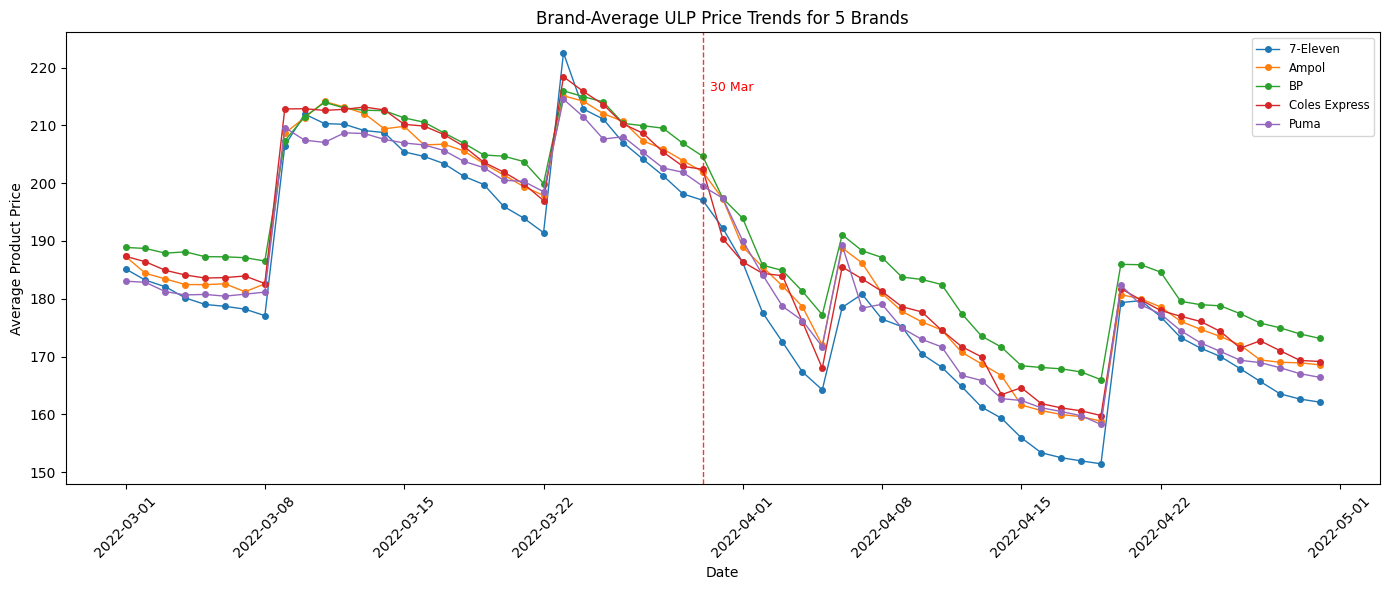

Saved Graphs\brand_average_ulp_price_trends_5_brands_sep_oct.png


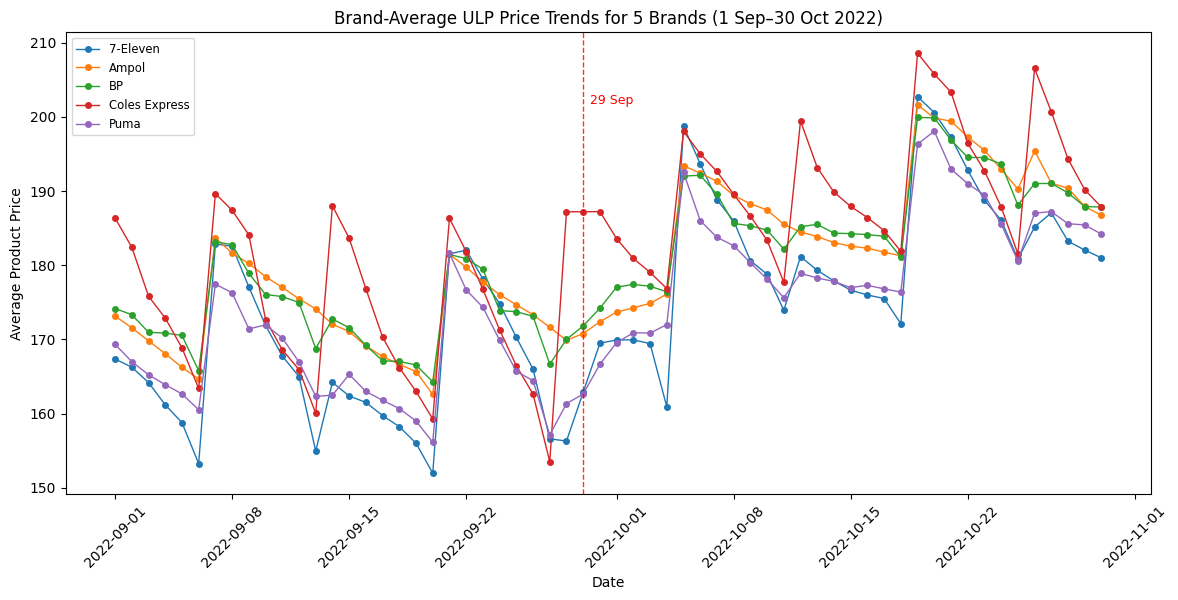

Saved Graphs\brand_average_ulp_price_trends_5_brands_full_2022.png


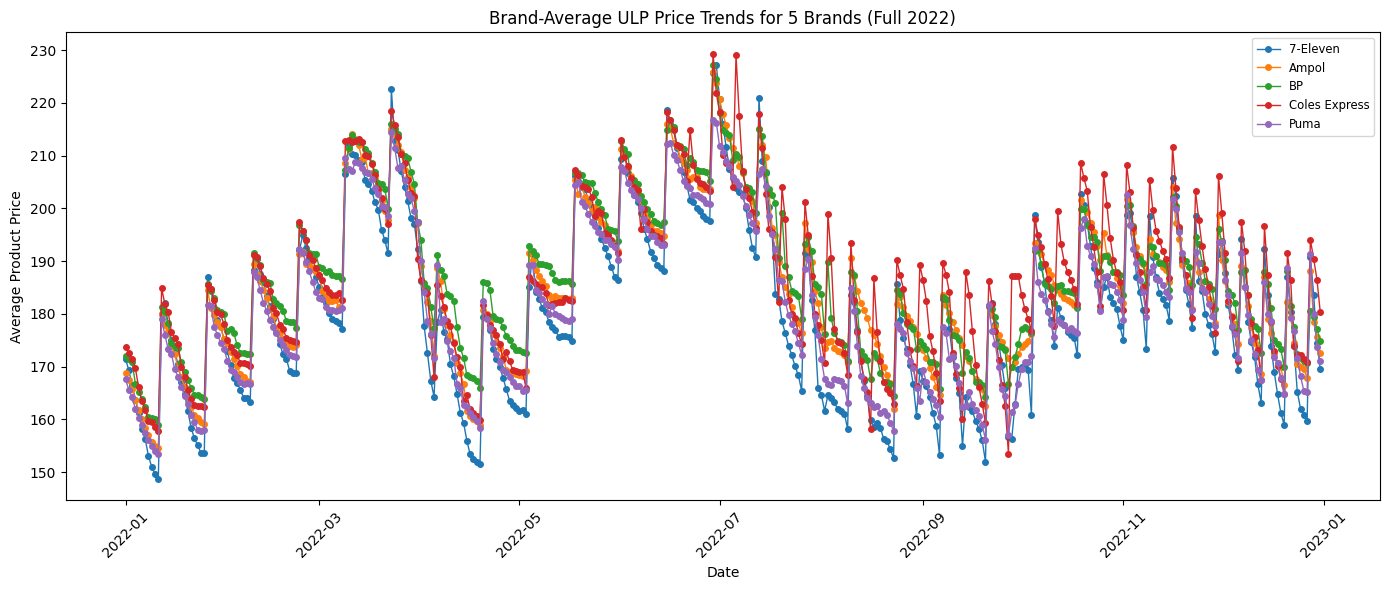

In [5]:
# Plot brand-average price trends for 5 brands
brand_plot_df = plot_df.copy()
brand_plot_df = brand_plot_df.dropna(subset=['BRAND_DESCRIPTION', 'PRODUCT_PRICE', 'PUBLISH_DATE'])

brand_counts = brand_plot_df['BRAND_DESCRIPTION'].value_counts().head(5).index.tolist()
brand_trends = (
    brand_plot_df[brand_plot_df['BRAND_DESCRIPTION'].isin(brand_counts)]
    .groupby(['PUBLISH_DATE', 'BRAND_DESCRIPTION'])['PRODUCT_PRICE']
    .mean()
    .unstack('BRAND_DESCRIPTION')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in brand_trends.columns:
    plt.plot(brand_trends.index, brand_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.axvline(pd.Timestamp('2022-03-30'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('30 Mar', xy=(pd.Timestamp('2022-03-30'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)

plt.title('Brand-Average ULP Price Trends for 5 Brands')
plt.xlabel('Date')
plt.ylabel('Average Product Price')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('brand_average_ulp_price_trends_5_brands.png')
plt.show()

# Replicate similar brand-average graph for 1 Sep to 30 Oct
brand_plot_sep = df.copy()
brand_plot_sep = brand_plot_sep.dropna(subset=['BRAND_DESCRIPTION', 'PRODUCT_PRICE', 'PUBLISH_DATE'])
brand_plot_sep = brand_plot_sep[(brand_plot_sep['PUBLISH_DATE'] >= '2022-09-01') & (brand_plot_sep['PUBLISH_DATE'] <= '2022-10-30')]

sep_brand_counts = brand_plot_sep['BRAND_DESCRIPTION'].value_counts().head(5).index.tolist()
sep_brand_trends = (
    brand_plot_sep[brand_plot_sep['BRAND_DESCRIPTION'].isin(sep_brand_counts)]
    .groupby(['PUBLISH_DATE', 'BRAND_DESCRIPTION'])['PRODUCT_PRICE']
    .mean()
    .unstack('BRAND_DESCRIPTION')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in sep_brand_trends.columns:
    plt.plot(sep_brand_trends.index, sep_brand_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.axvline(pd.Timestamp('2022-09-29'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('29 Sep', xy=(pd.Timestamp('2022-09-29'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)

plt.title('Brand-Average ULP Price Trends for 5 Brands (1 Sep–30 Oct 2022)')
plt.xlabel('Date')
plt.ylabel('Average Product Price')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
save_fig('brand_average_ulp_price_trends_5_brands_sep_oct.png')
plt.show()

# Plot brand-average price trends for 5 brands over the full 2022 year
brand_plot_year = df.copy()
brand_plot_year = brand_plot_year.dropna(subset=['BRAND_DESCRIPTION', 'PRODUCT_PRICE', 'PUBLISH_DATE'])
brand_plot_year = brand_plot_year[(brand_plot_year['PUBLISH_DATE'] >= '2022-01-01') & (brand_plot_year['PUBLISH_DATE'] <= '2022-12-31')]

year_brand_counts = brand_plot_year['BRAND_DESCRIPTION'].value_counts().head(5).index.tolist()
year_brand_trends = (
    brand_plot_year[brand_plot_year['BRAND_DESCRIPTION'].isin(year_brand_counts)]
    .groupby(['PUBLISH_DATE', 'BRAND_DESCRIPTION'])['PRODUCT_PRICE']
    .mean()
    .unstack('BRAND_DESCRIPTION')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in year_brand_trends.columns:
    plt.plot(year_brand_trends.index, year_brand_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.title('Brand-Average ULP Price Trends for 5 Brands (Full 2022)')
plt.xlabel('Date')
plt.ylabel('Average Product Price')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('brand_average_ulp_price_trends_5_brands_full_2022.png')
plt.show()

Saved Graphs\cycle_lengths_big_jump_restarts_by_brand.png


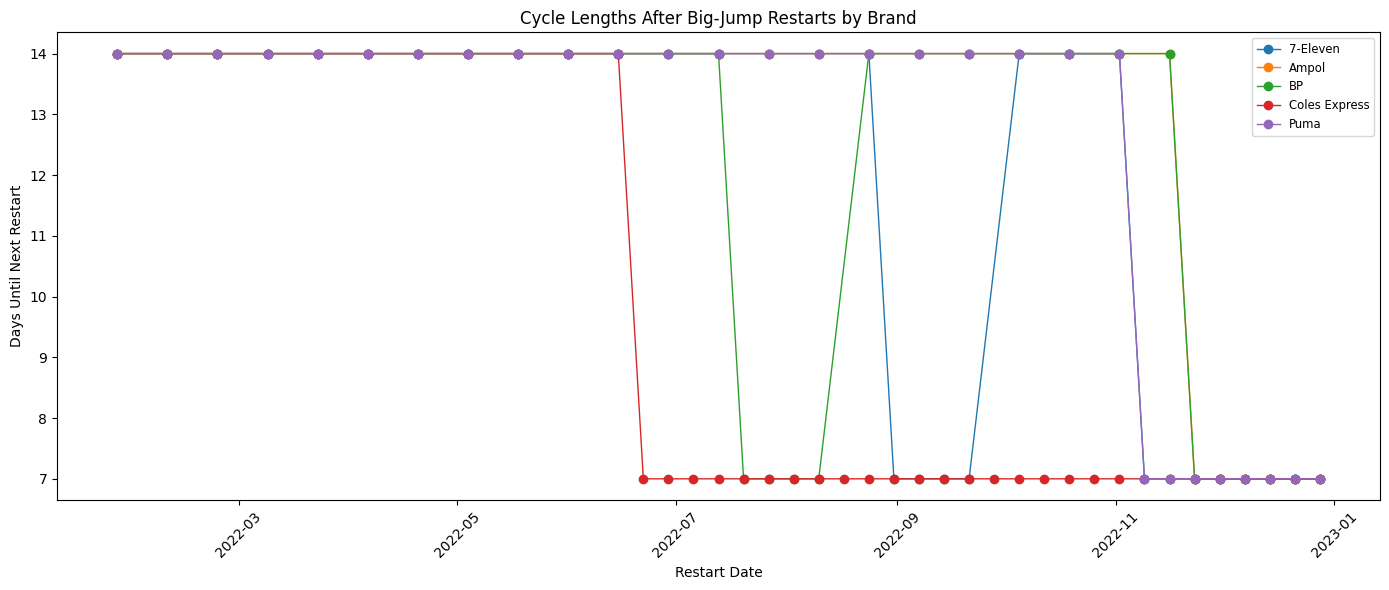

In [7]:
# Detect cycle restarts from 1-day increases over 5 cents and summarize cycle lengths
cycle_brand_trends = year_brand_trends.copy()

cycle_records = []
for brand in cycle_brand_trends.columns:
    changes = cycle_brand_trends[brand].diff()
    restarts = changes[changes > 8].index
    if len(restarts) == 0:
        continue
    lengths = restarts.to_series().diff().dt.days
    cycle_records.append(
        pd.DataFrame({
            'Brand': brand,
            'RestartDate': restarts,
            'CycleLengthDays': lengths.values,
            'PriceJump': changes[restarts].values
        })
    )

cycle_df = pd.concat(cycle_records, ignore_index=True) if cycle_records else pd.DataFrame(columns=['Brand', 'RestartDate', 'CycleLengthDays', 'PriceJump'])
cycle_df_sorted = cycle_df.sort_values(['Brand', 'RestartDate'])

# Plot how cycle lengths vary across the year
plt.figure(figsize=(14, 6))
for brand, brand_df in cycle_df_sorted.groupby('Brand'):
    plt.plot(brand_df['RestartDate'], brand_df['CycleLengthDays'], marker='o', linewidth=1, label=brand)

plt.title('Cycle Lengths After Big-Jump Restarts by Brand')
plt.xlabel('Restart Date')
plt.ylabel('Days Until Next Restart')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('cycle_lengths_big_jump_restarts_by_brand.png')
plt.show()

In [ ]:
# Import the petrol TGP page from the Excel file

tgp_path = 'NSW_WA_2022_fuelprice/AIP_TGP_Data_05-Jun-2026.xlsx'
tgp_df = pd.read_excel(tgp_path, sheet_name='Petrol TGP')

tgp_df.rename(columns={tgp_df.columns[0]: 'Date'}, inplace=True)
tgp_df['Date'] = pd.to_datetime(tgp_df['Date'], errors='coerce')

tgp_perth_2022 = tgp_df.loc[
    (tgp_df['Date'].dt.year == 2022),
    ['Date', 'Perth']
].copy()


# Plot terminal gate price around key event windows
window_days = 90
for center_date, label in [(pd.Timestamp('2022-06-01'), '01 Jun'), (pd.Timestamp('2022-09-28'), '28 Sep')]:
    start = center_date - pd.Timedelta(days=window_days)
    end = center_date + pd.Timedelta(days=window_days)
    window_df = tgp_perth_2022.set_index('Date').loc[start:end]

    plt.figure(figsize=(12, 5))
    plt.plot(window_df.index, window_df['Perth'], marker='o', linewidth=1, markersize=4)
    plt.axvline(center_date, color='red', linestyle='--', linewidth=1, alpha=0.8)
    plt.annotate(label, xy=(center_date, plt.gca().get_ylim()[1] * 0.95),
                 xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
    plt.title(f'Perth Petrol TGP: 14-Day Window Around {label} 2022')
    plt.xlabel('Date')
    plt.ylabel('Perth Petrol TGP')
    plt.xticks(rotation=45)
    plt.tight_layout()
    save_fig(f'perth_petrol_tgp_14day_window_{label.replace(" ", "_")}.png')
    plt.show()

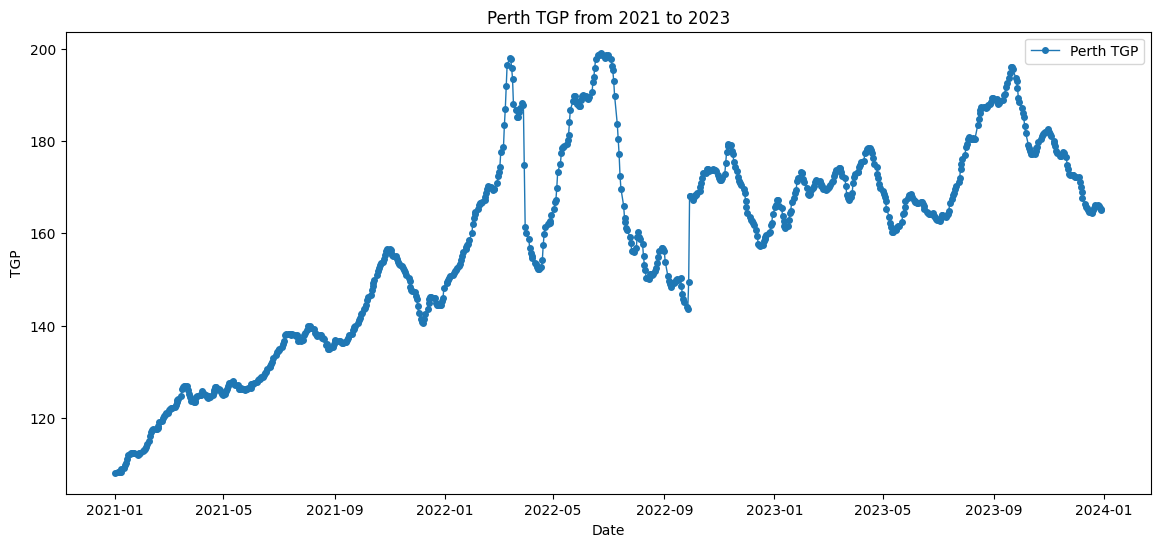

In [42]:
#Select from tgp_df of 2021-2023 and Perth TGP values
tgp_perth = tgp_df.loc[(tgp_df['Date'] >= '2021-01-01') & (tgp_df['Date'] <= '2023-12-31'), ['Date', 'Perth']].copy()

#Plot Perth TGP from 2021 to 2023
plt.figure(figsize=(14, 6))
plt.plot(tgp_perth['Date'], tgp_perth['Perth'], marker='o', linewidth=1, markersize=4, label='Perth TGP')
plt.xlabel('Date')
plt.ylabel('TGP')
plt.title('Perth TGP from 2021 to 2023')
plt.legend()
plt.show()


Saved Graphs\brand_average_margin_over_tgp_full_2022.png


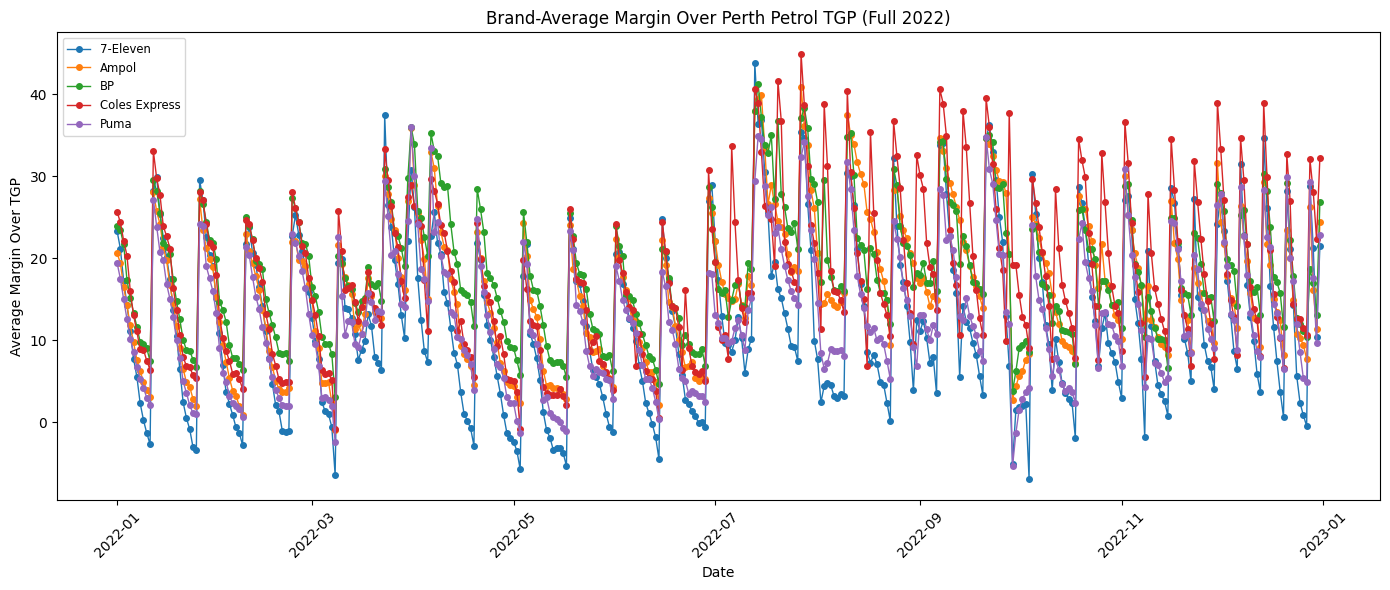

In [9]:
# Merge Perth petrol TGP into the main fuel price dataframe and compute margin

# Rename the Perth column for a clear merge
perth_tgp = tgp_perth_2022.rename(columns={'Perth': 'TGP_Perth'}).set_index('Date').sort_index()

# Forward-fill TGP across weekends so weekend rows use the previous Friday's price
perth_tgp_full = perth_tgp.reindex(
    pd.date_range(start=perth_tgp.index.min(), end=perth_tgp.index.max(), freq='D')
)
perth_tgp_full['TGP_Perth'] = perth_tgp_full['TGP_Perth'].ffill()
perth_tgp_full = perth_tgp_full.reset_index().rename(columns={'index': 'Date'})

# Merge on date and compute margin over TGP
# Keep only matching dates from the dataset and preserve the existing df structure
merged_df = df.merge(
    perth_tgp_full[['Date', 'TGP_Perth']],
    left_on='PUBLISH_DATE',
    right_on='Date',
    how='left'
)
merged_df.drop(columns=['Date'], inplace=True)

# Fill remaining missing Perth TGP rows with the specified fallback value
merged_df['TGP_Perth'] = merged_df['TGP_Perth'].fillna(148.1)
merged_df['margin'] = merged_df['PRODUCT_PRICE'] - merged_df['TGP_Perth']

df = merged_df

# Plot brand-average margin over TGP for the full 2022 year
margin_plot_df = df.dropna(subset=['BRAND_DESCRIPTION', 'margin', 'PUBLISH_DATE'])
margin_plot_df = margin_plot_df[(margin_plot_df['PUBLISH_DATE'] >= '2022-01-01') & (margin_plot_df['PUBLISH_DATE'] <= '2022-12-31')]

brand_counts = margin_plot_df['BRAND_DESCRIPTION'].value_counts().head(5).index.tolist()
brand_margin_trends = (
    margin_plot_df[margin_plot_df['BRAND_DESCRIPTION'].isin(brand_counts)]
    .groupby(['PUBLISH_DATE', 'BRAND_DESCRIPTION'])['margin']
    .mean()
    .unstack('BRAND_DESCRIPTION')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in brand_margin_trends.columns:
    plt.plot(brand_margin_trends.index, brand_margin_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.title('Brand-Average Margin Over Perth Petrol TGP (Full 2022)')
plt.xlabel('Date')
plt.ylabel('Average Margin Over TGP')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('brand_average_margin_over_tgp_full_2022.png')
plt.show()

Saved Graphs\margin_window_30_mar_2022.png


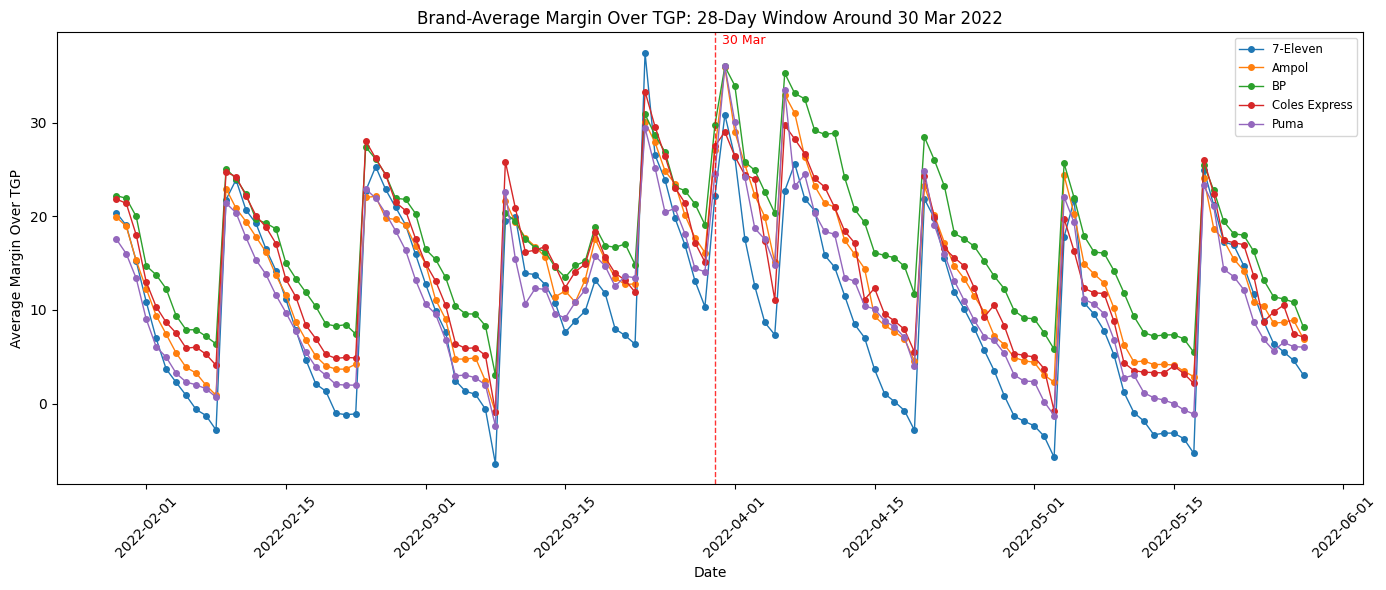

Saved Graphs\margin_window_29_sep_2022.png


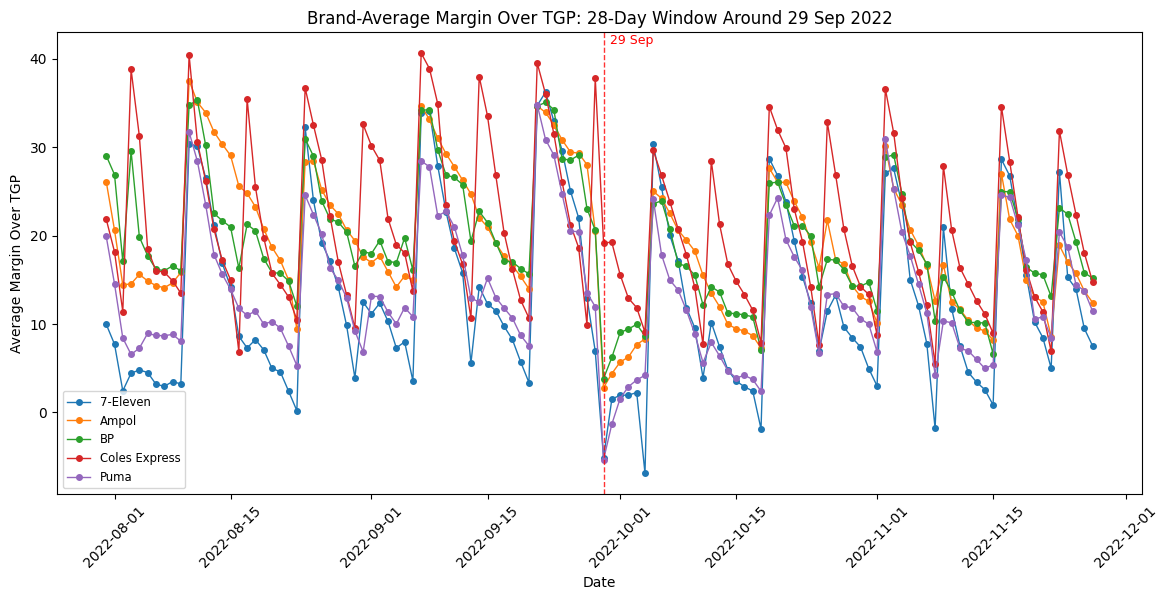

In [11]:
# Zoom in on 28-day windows around key dates for brand-average margin over TGP

window_days = 60

# 30 Mar 2022 window
center_date_mar = pd.Timestamp('2022-03-30')
start_mar = center_date_mar - pd.Timedelta(days=window_days)
end_mar = center_date_mar + pd.Timedelta(days=window_days - 1)
mar_window = brand_margin_trends.loc[start_mar:end_mar]

plt.figure(figsize=(14, 6))
for brand in mar_window.columns:
    plt.plot(mar_window.index, mar_window[brand], marker='o', linewidth=1, markersize=4, label=brand)
plt.axvline(center_date_mar, color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('30 Mar', xy=(center_date_mar, plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
plt.title('Brand-Average Margin Over TGP: 28-Day Window Around 30 Mar 2022')
plt.xlabel('Date')
plt.ylabel('Average Margin Over TGP')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
save_fig('margin_window_30_mar_2022.png')
plt.show()

# 28 Sep 2022 window
center_date_sep = pd.Timestamp('2022-09-29')
start_sep = center_date_sep - pd.Timedelta(days=window_days)
end_sep = center_date_sep + pd.Timedelta(days=window_days - 1)
sep_window = brand_margin_trends.loc[start_sep:end_sep]

plt.figure(figsize=(14, 6))
for brand in sep_window.columns:
    plt.plot(sep_window.index, sep_window[brand], marker='o', linewidth=1, markersize=4, label=brand)
plt.axvline(center_date_sep, color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('29 Sep', xy=(center_date_sep, plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
plt.title('Brand-Average Margin Over TGP: 28-Day Window Around 29 Sep 2022')
plt.xlabel('Date')
plt.ylabel('Average Margin Over TGP')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
save_fig('margin_window_29_sep_2022.png')
plt.show()

Saved Graphs\station_price_trends_30_Mar.png


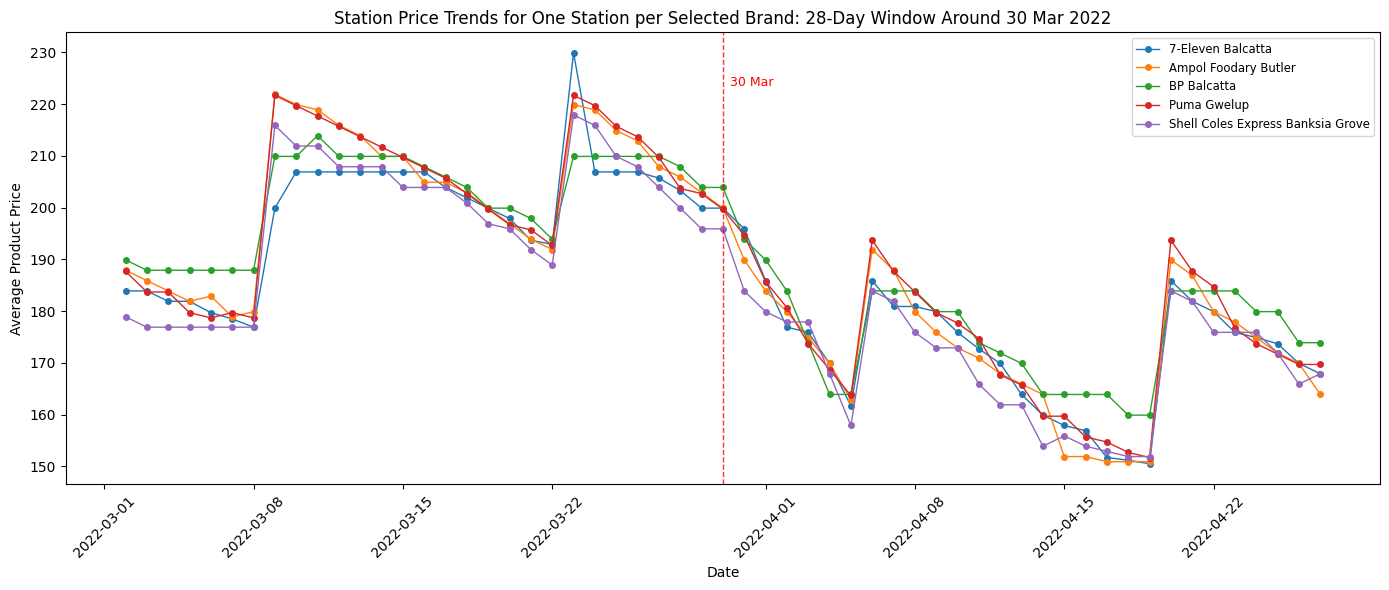

Saved Graphs\station_price_trends_29_Sep.png


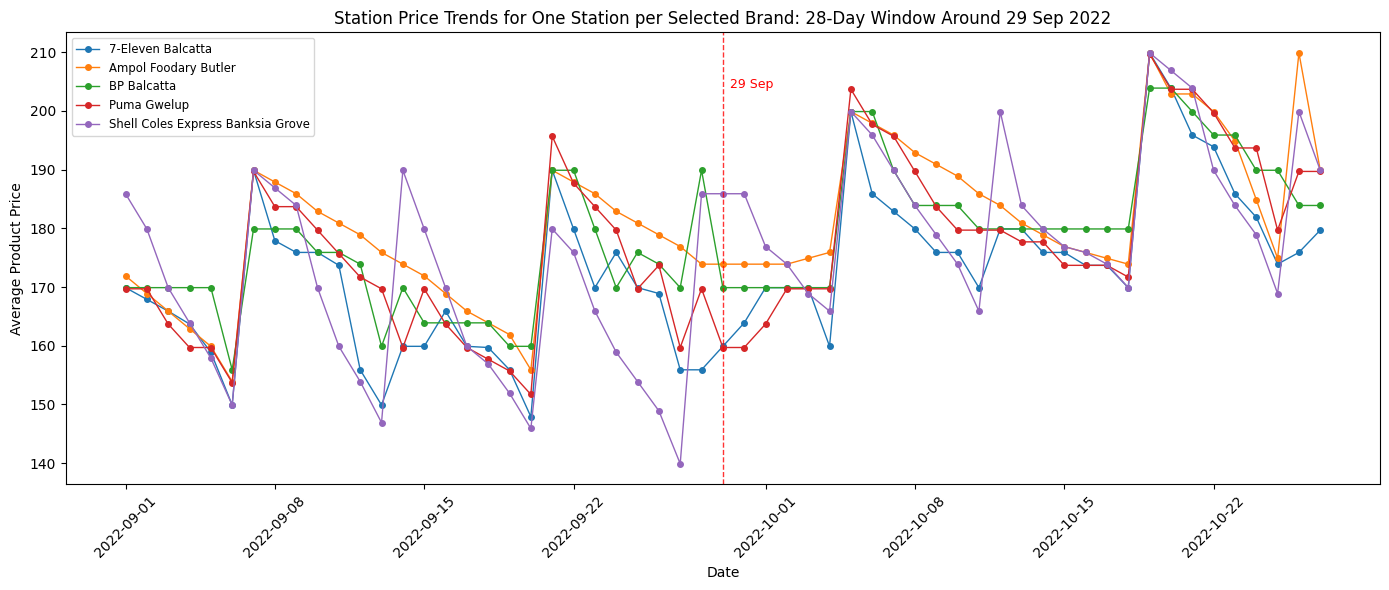

In [19]:
# Pick one station from each of the five brands selected above and plot price trends around the event windows

brand_counts = df['BRAND_DESCRIPTION'].value_counts().head(5).index.tolist()

postcode_df = df.copy()
postcode_df['POSTCODE'] = pd.to_numeric(postcode_df['POSTCODE'], errors='coerce')
postcode_df = postcode_df[(postcode_df['POSTCODE'] >= 6000) & (postcode_df['POSTCODE'] <= 6038)]

# Choose one representative station per selected brand within the postcode filter
brand_station = (
    postcode_df.dropna(subset=['BRAND_DESCRIPTION', 'TRADING_NAME'])
      .loc[postcode_df['BRAND_DESCRIPTION'].isin(brand_counts)]
      .groupby(['BRAND_DESCRIPTION', 'TRADING_NAME'])['PUBLISH_DATE']
      .count()
      .reset_index(name='count')
      .sort_values(['BRAND_DESCRIPTION', 'count'], ascending=[True, False])
      .groupby('BRAND_DESCRIPTION')
      .first()
      .reset_index()
)

selected_stations = postcode_df[postcode_df['TRADING_NAME'].isin(brand_station['TRADING_NAME'])].copy()
selected_stations = selected_stations.dropna(subset=['TRADING_NAME', 'PRODUCT_PRICE', 'PUBLISH_DATE'])

window_days = 28
for center_date, label in [(pd.Timestamp('2022-03-30'), '30 Mar'), (pd.Timestamp('2022-09-29'), '29 Sep')]:
    start = center_date - pd.Timedelta(days=window_days)
    end = center_date + pd.Timedelta(days=window_days)
    window_df = selected_stations[(selected_stations['PUBLISH_DATE'] >= start) & (selected_stations['PUBLISH_DATE'] <= end)]
    trend = (
        window_df.groupby(['PUBLISH_DATE', 'TRADING_NAME'])['PRODUCT_PRICE']
        .mean()
        .unstack('TRADING_NAME')
        .sort_index()
    )

    plt.figure(figsize=(14, 6))
    for station in trend.columns:
        plt.plot(trend.index, trend[station], marker='o', linewidth=1, markersize=4, label=station)

    plt.axvline(center_date, color='red', linestyle='--', linewidth=1, alpha=0.8)
    plt.annotate(label, xy=(center_date, plt.gca().get_ylim()[1] * 0.95),
                 xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
    plt.title(f'Station Price Trends for One Station per Selected Brand: 28-Day Window Around {label} 2022')
    plt.xlabel('Date')
    plt.ylabel('Average Product Price')
    plt.xticks(rotation=45)
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    save_fig(f'station_price_trends_{label.replace(" ", "_")}.png')
    plt.show()

In [ ]:
# Export cleaned combined dataset with TGP and margin data

cleaned_combined_df = df.copy()
cleaned_combined_df.to_csv('cleaned_combined_df_with_tgp_margin.csv', index=False)


Saved Graphs\station_week_cycle_state_proportions.png


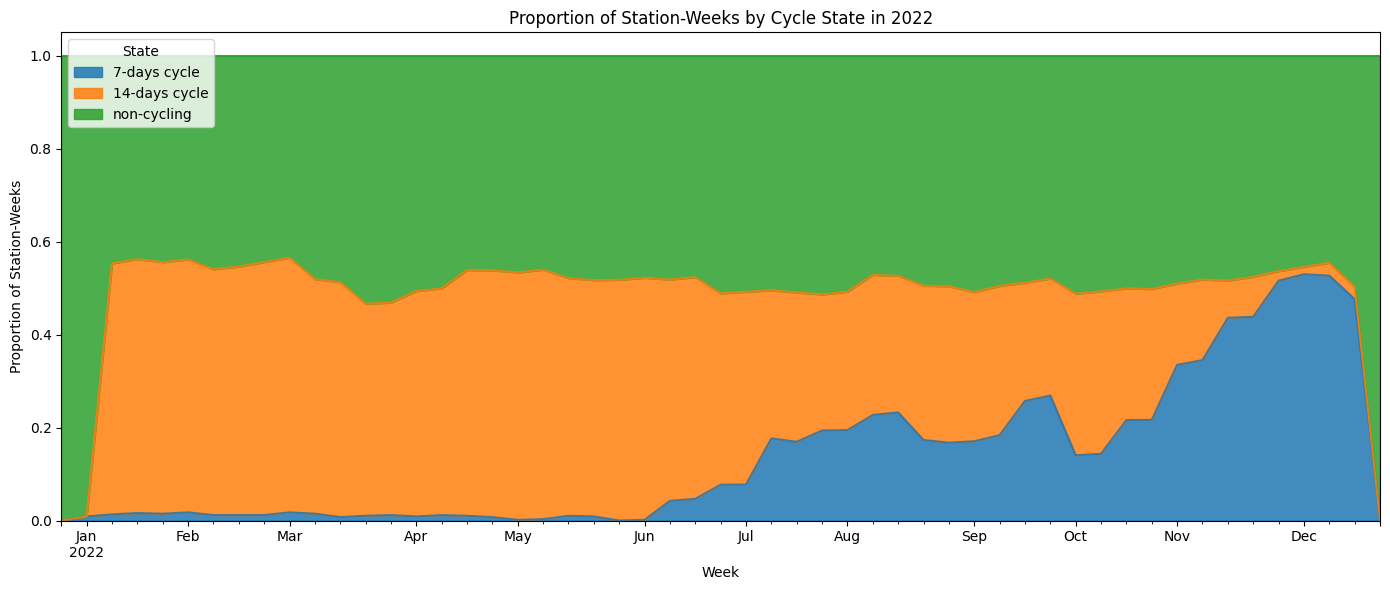

In [13]:
# Categorize each station-week into cycle states and plot proportions
station_cycle_df = df[['TRADING_NAME', 'PUBLISH_DATE', 'PRODUCT_PRICE']].dropna(subset=['TRADING_NAME', 'PUBLISH_DATE', 'PRODUCT_PRICE']).copy()
station_cycle_df = station_cycle_df.sort_values(['TRADING_NAME', 'PUBLISH_DATE'])
station_cycle_df['price_diff'] = station_cycle_df.groupby('TRADING_NAME')['PRODUCT_PRICE'].diff()
station_cycle_df['restart'] = station_cycle_df['price_diff'] > 10

restart_dates = station_cycle_df.loc[station_cycle_df['restart'], ['TRADING_NAME', 'PUBLISH_DATE']]

interval_rows = []
for name, group in restart_dates.groupby('TRADING_NAME'):
    dates = list(group['PUBLISH_DATE'])
    for i in range(len(dates) - 1):
        start = dates[i]
        end = dates[i + 1]
        cycle_len = (end - start).days
        if 5 <= cycle_len <= 9:
            state = '7-days cycle'
        elif 11 <= cycle_len <= 17:
            state = '14-days cycle'
        else:
            state = 'non-cycling'
        interval_rows.append({
            'TRADING_NAME': name,
            'start': start,
            'end': end - pd.Timedelta(days=1),
            'state': state
        })

intervals_df = pd.DataFrame(interval_rows)
if not intervals_df.empty:
    intervals_df['PUBLISH_DATE'] = intervals_df.apply(
        lambda row: pd.date_range(row['start'], row['end'], freq='D'),
        axis=1
    )
    intervals_exploded = intervals_df.explode('PUBLISH_DATE')[['TRADING_NAME', 'PUBLISH_DATE', 'state']]
else:
    intervals_exploded = pd.DataFrame(columns=['TRADING_NAME', 'PUBLISH_DATE', 'state'])

station_weeks = station_cycle_df[['TRADING_NAME', 'PUBLISH_DATE']].drop_duplicates().copy()
station_weeks['week'] = station_weeks['PUBLISH_DATE'].dt.to_period('W-MON').dt.start_time
station_weeks = station_weeks.merge(intervals_exploded, on=['TRADING_NAME', 'PUBLISH_DATE'], how='left')
station_weeks['state'] = station_weeks['state'].fillna('non-cycling')

station_week_state = station_weeks.groupby(['week', 'TRADING_NAME'])['state'] \
    .agg(lambda x: x.value_counts().idxmax()).reset_index()

weekly_counts = station_week_state.groupby(['week', 'state']).size().unstack(fill_value=0)
weekly_props = weekly_counts.div(weekly_counts.sum(axis=1), axis=0)
weekly_props = weekly_props.reindex(columns=['7-days cycle', '14-days cycle', 'non-cycling']).fillna(0)

plt.figure(figsize=(14, 6))
weekly_props.plot(kind='area', stacked=True, alpha=0.85, ax=plt.gca())
plt.title('Proportion of Station-Weeks by Cycle State in 2022')
plt.xlabel('Week')
plt.ylabel('Proportion of Station-Weeks')
plt.legend(title='State', loc='upper left')
plt.tight_layout()
save_fig('station_week_cycle_state_proportions.png')
plt.show()

In [35]:
SE_df = df[df['BRAND_DESCRIPTION'] == '7-Eleven']
Coles_df = df[df['BRAND_DESCRIPTION'] == 'Coles Express']
SE_df['TRADING_NAME'].unique()
Coles_df['TRADING_NAME'].unique()

<StringArray>
[                    'Coles Express Albany Orana',
                   'Shell Coles Express Armadale',
              'Shell Coles Express Banksia Grove',
                  'Shell Coles Express Bayswater',
                    'Shell Coles Express Beeliar',
                    'Shell Coles Express Bentley',
                 'Shell Coles Express Bibra Lake',
                     'Shell Coles Express Bicton',
                    'Shell Coles Express Boulder',
                  'Shell Coles Express Brentwood',
                  'Shell Coles Express Brookdale',
                     'Shell Coles Express Broome',
                 'Shell Coles Express Bull Creek',
            'Shell Coles Express Bunbury Gateway',
                    'Shell Coles Express Bunbury',
                  'Shell Coles Express Busselton',
                     'Shell Coles Express Butler',
               'Shell Coles Express Canning Vale',
             'Shell Coles Express Casuarina (WA)',
                 

Text(0.5, 0, 'Date')

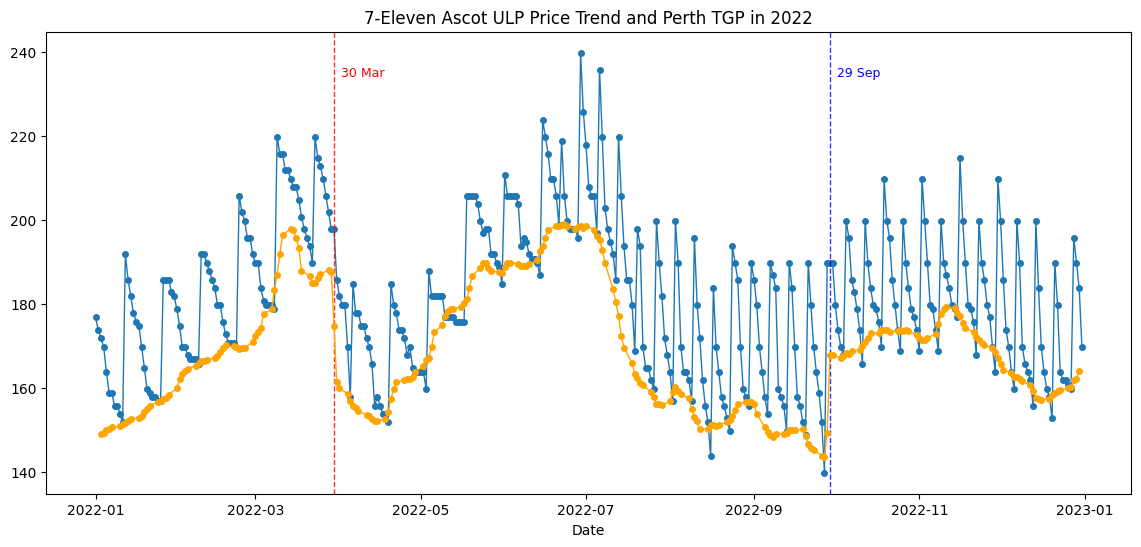

In [36]:
eg_station = df[df['TRADING_NAME'] == 'Shell Coles Express Bull Creek']


plot_df = eg_station[(eg_station['PUBLISH_DATE'] >= '2022-01-01') & (eg_station['PUBLISH_DATE'] <= '2022-12-31')].copy()
plt.figure(figsize=(14, 6))
plt.plot(plot_df['PUBLISH_DATE'], plot_df['PRODUCT_PRICE'], marker='o', linewidth=1, markersize=4, label='7-Eleven Ascot')
plt.title('7-Eleven Ascot ULP Price Trend in 2022')

# Add a vertical line for the 30 Mar 2022 event
plt.axvline(pd.Timestamp('2022-03-30'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('30 Mar', xy=(pd.Timestamp('2022-03-30'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
# Add a vertical line for the 29 Sep 2022 event
plt.axvline(pd.Timestamp('2022-09-29'), color='blue', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('29 Sep', xy=(pd.Timestamp('2022-09-29'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='blue', fontsize=9)

#Add tgp price below the price trend of the same window
tgp_window = tgp_perth_2022[(tgp_perth_2022['Date'] >= '2022-01-01') & (tgp_perth_2022['Date'] <= '2022-12-31')].copy()
plt.plot(tgp_window['Date'], tgp_window['Perth'], marker='o', linewidth=1, markersize=4, label='Perth TGP', color='orange')
plt.title('7-Eleven Ascot ULP Price Trend and Perth TGP in 2022')
plt.xlabel('Date')

In [ ]:
# Filter Perth postcode range and extract cycling stations
# Definition: Station i is a cycling station if Δ pit >= 6 cpl at least 15 times.

perth_df = df.copy()
perth_df['POSTCODE'] = pd.to_numeric(perth_df['POSTCODE'], errors='coerce')
perth_df = perth_df[perth_df['POSTCODE'].between(6000, 6040)].copy()
perth_df['PUBLISH_DATE'] = pd.to_datetime(perth_df['PUBLISH_DATE'])
perth_df = perth_df.sort_values(['TRADING_NAME', 'PUBLISH_DATE']).reset_index(drop=True)

# Station-level price change within each trading name
perth_df['delta_price'] = perth_df.groupby('TRADING_NAME')['PRODUCT_PRICE'].diff()

# Count how many times each station records a jump of at least 6 cpl
cycling_station_counts = (
    perth_df.groupby('TRADING_NAME')['delta_price']
    .apply(lambda s: (s >= 6).sum())
    .reset_index(name='delta_pit_ge_6_count')
)

cycling_station_names = cycling_station_counts.loc[
    cycling_station_counts['delta_pit_ge_6_count'] >= 15,
    'TRADING_NAME'
]

Perth_Cycling_df = perth_df[perth_df['TRADING_NAME'].isin(cycling_station_names)].copy()

print(f"Perth postcode filter (6000-6040) rows: {len(perth_df)}")
print(f"Cycling stations found: {Perth_Cycling_df['TRADING_NAME'].nunique()}")
print(f"Cycling observations retained: {len(Perth_Cycling_df)}")
print("\nCycling station counts (top 20):")
print(cycling_station_counts.sort_values('delta_pit_ge_6_count', ascending=False).head(20))


Perth postcode filter (6000-6040) rows: 33349
Cycling stations found: 94
Cycling observations retained: 32703

Cycling station counts (top 20):
                          TRADING_NAME  delta_pit_ge_6_count
17        Ampol Foodary North Wanneroo                    54
101                       Vibe Subiaco                    51
8             Ampol Foodary Doubleview                    44
87    Shell Coles Express Osborne Park                    44
20               Ampol Foodary Subiaco                    43
83        Shell Coles Express Kingsley                    42
95                  United Northbridge                    42
93              United Hepburn Heights                    42
79        Shell Coles Express Clarkson                    41
84     Shell Coles Express Mosman Park                    41
80        Shell Coles Express Duncraig                    41
88           Shell Coles Express Perth                    41
90    Shell Coles Express Warwick (WA)                    41
81

In [30]:
unique_stations = Perth_Cycling_df[['TRADING_NAME', 'POSTCODE']].drop_duplicates().sort_values('TRADING_NAME')
print(unique_stations.to_string(index=False))

                            TRADING_NAME  POSTCODE
                       7-Eleven Balcatta      6021
                  7-Eleven Banksia Grove      6031
                         7-Eleven Butler      6036
                      7-Eleven Joondalup      6027
                       7-Eleven Stirling      6021
                    Ampol Foodary Butler      6036
                    Ampol Foodary Carine      6020
                  Ampol Foodary Clarkson      6030
                Ampol Foodary Doubleview      6018
                Ampol Foodary East Perth      6000
               Ampol Foodary Glendalough      6016
                 Ampol Foodary Joondalup      6027
                 Ampol Foodary Karrinyup      6018
                  Ampol Foodary Kingsley      6026
               Ampol Foodary Leederville      6007
               Ampol Foodary Mosman Park      6012
                  Ampol Foodary Nedlands      6009
            Ampol Foodary North Wanneroo      6032
                Ampol Foodary N

In [36]:
# Load WA service stations coordinates
wa_coords_path = os.path.join(graphs_dir, '..', 'NSW_WA_2022_fuelprice', 'WA', 'wa_service_stations_coordinates.csv')
wa_coords_df = pd.read_csv(wa_coords_path)

# Select only the station name and coordinates
wa_coords_df = wa_coords_df[['Station Name', 'Latitude', 'Longitude']]

# Merge with Perth_Cycling_df by station name
# wa_coords_df has 'Station Name', Perth_Cycling_df has 'TRADING_NAME'
Perth_Cycling_df_merged = Perth_Cycling_df.merge(
    wa_coords_df, 
    left_on='TRADING_NAME', 
    right_on='Station Name', 
    how='left'
)

# Drop the duplicate Station Name column
Perth_Cycling_df_merged = Perth_Cycling_df_merged.drop(columns=['Station Name'])

# Export to CSV
Perth_Cycling_df_merged.to_csv('Perth_Cycling_df.csv', index=False)
print("\nExported: Perth_Cycling_df.csv")



Exported: Perth_Cycling_df.csv
